# ResNet-50 — Plant Disease Classification
**Model**: microsoft/resnet-50 (HuggingFace)  
**Dataset**: SPLIT_DATA_8010 (80/10/10, 12 kelas, struktur subfolder per kelas)  


## Cell 1 — Install Library + Mount Google Drive

In [ ]:
# Cell 1: Install library + Mount Google Drive
!pip install transformers accelerate scikit-learn matplotlib seaborn tqdm -q

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Cell 2 — Konfigurasi Global

In [ ]:
import os
import torch
import numpy as np

# ============================================================
# Hanya MODEL_NAME & SAVE_DIR yang berbeda
# ============================================================
DATA_DIR    = '/content/drive/MyDrive/SPLIT_DATA_8010'
MODEL_NAME  = 'microsoft/resnet-50'
SAVE_DIR    = '/content/drive/MyDrive/MODEL_RESNET50'

NUM_CLASSES = 12    #jumlah kelas penyakit yang diklasifikasikan.
BATCH_SIZE  = 32    #jumlah gambar yang diproses dalam satu kali iterasi.
NUM_EPOCHS  = 30    #jumlah maksimum proses pelatihan.
LR          = 1e-3  #nilai learning rate awal yang mengatur besar kecilnya pembaruan bobot model.
LR_PATIENCE = 3     #learning rate akan diturunkan jika validasi tidak membaik selama 3 epoch.
ES_PATIENCE = 7     #pelatihan dihentikan lebih awal (Early Stopping) jika tidak ada peningkatan selama 7 epoch.
IMAGE_SIZE  = 224   #ukuran citra masukan sesuai standar ResNet-50.
SEED        = 42    #digunakan agar hasil pelatihan dapat direproduksi.

os.makedirs(SAVE_DIR, exist_ok=True)
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Konfigurasi:')
print(f'  Model      : {MODEL_NAME}')
print(f'  Data dir   : {DATA_DIR}')
print(f'  Save dir   : {SAVE_DIR}')
print(f'  Kelas      : {NUM_CLASSES}')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  Max epochs : {NUM_EPOCHS}')
print(f'  LR awal    : {LR}')
print(f'  Device     : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU        : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Konfigurasi:
  Model      : microsoft/resnet-50
  Data dir   : /content/drive/MyDrive/SPLIT_DATA_8010
  Save dir   : /content/drive/MyDrive/MODEL_RESNET50
  Kelas      : 12
  Batch size : 32
  Max epochs : 30
  LR awal    : 0.001
  Device     : cuda
  GPU        : Tesla T4
  VRAM       : 15.6 GB


## Cell 3 — Import Library

In [ ]:
# Cell 3: Import library
import json
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from transformers import ResNetForImageClassification
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

print('Library berhasil diimport')

Library berhasil diimport


## Cell 4 — Dataset & DataLoader (ImageFolder)

In [ ]:
# Cell 4: Dataset & DataLoader menggunakan ImageFolder

# ── Augmentasi train ───
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ── Dataset menggunakan ImageFolder ─────────────────────────
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'),   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'),  transform=val_test_transform)

# Nama kelas diambil otomatis dari sorted subfolder names
CLASSES = train_dataset.classes
assert len(CLASSES) == NUM_CLASSES, (
    f'Expected {NUM_CLASSES} classes, got {len(CLASSES)}: {CLASSES}'
)

# ── DataLoader ───────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train  : {len(train_dataset)} gambar | {len(train_loader)} batch')
print(f'Val    : {len(val_dataset)} gambar | {len(val_loader)} batch')
print(f'Test   : {len(test_dataset)} gambar | {len(test_loader)} batch')
print(f'')
print(f'Kelas terdeteksi ({len(CLASSES)}):')
for i, cls in enumerate(CLASSES):
    count = sum(1 for _, label in train_dataset.samples if label == i)
    print(f'  {i:2d}. {cls:<45} {count} gambar')

Train  : 2640 gambar | 83 batch
Val    : 324 gambar | 11 batch
Test   : 337 gambar | 11 batch

Kelas terdeteksi (12):
   0. apple_scab                                    220 gambar
   1. bacterial_spot                                220 gambar
   2. black_rot                                     220 gambar
   3. cedar_apple_rust                              220 gambar
   4. cercospora                                    220 gambar
   5. common_rust                                   220 gambar
   6. early_blight                                  220 gambar
   7. grape_black_rot                               220 gambar
   8. grape_esca_black_measles                      220 gambar
   9. grape_leaf_blight_isariopsis_leaf_spot        220 gambar
  10. late_blight                                   220 gambar
  11. leaf_blight                                   220 gambar


## Cell 5 — Load Model ResNet-50

In [ ]:
# Cell 5: Load model ResNet-50 dari HuggingFace
model = ResNetForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Model            : {MODEL_NAME}')
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}')
print(f'Num classes      : {NUM_CLASSES}')
print(f'Device           : {DEVICE}')
print()
print(model.classifier)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

ResNetForImageClassification LOAD REPORT from: microsoft/resnet-50
Key                 | Status   |                                                                                           
--------------------+----------+-------------------------------------------------------------------------------------------
classifier.1.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 2048]) vs model:torch.Size([12, 2048])
classifier.1.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([12])            

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model            : microsoft/resnet-50
Total params     : 23,532,620
Trainable params : 23,532,620
Num classes      : 12
Device           : cuda

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=2048, out_features=12, bias=True)
)


## Cell 6 — Optimizer + Scheduler + EarlyStopping

In [ ]:
# Cell 6: Optimizer + Scheduler + EarlyStopping

# ── Loss & Optimizer ────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# ── Scheduler ───────────────────────────────────────────────
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=LR_PATIENCE, factor=0.5
)

# ── Early Stopping ──────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=7, min_delta=1e-4, save_path=None):
        self.patience   = patience
        self.min_delta  = min_delta
        self.save_path  = save_path
        self.best_loss  = float('inf')
        self.counter    = 0
        self.best_model = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_model = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if self.save_path:
                torch.save(self.best_model, self.save_path)
                print(f'   Best model disimpan (val_loss={val_loss:.4f})')
            return False
        else:
            self.counter += 1
            print(f'   EarlyStopping: {self.counter}/{self.patience}')
            return self.counter >= self.patience


best_model_path = os.path.join(SAVE_DIR, 'resnet50_best.pt')
early_stopping  = EarlyStopping(patience=ES_PATIENCE, save_path=best_model_path)

print(f'Optimizer    : Adam  (lr={LR}, weight_decay=1e-4)')
print(f'Scheduler    : ReduceLROnPlateau  (patience={LR_PATIENCE}, factor=0.5)')
print(f'EarlyStopping: patience={ES_PATIENCE}')
print(f'Best model   : {best_model_path}')

Optimizer    : Adam  (lr=0.001, weight_decay=1e-4)
Scheduler    : ReduceLROnPlateau  (patience=3, factor=0.5)
EarlyStopping: patience=7
Best model   : /content/drive/MyDrive/MODEL_RESNET50/resnet50_best.pt


## Cell 7 — Training Loop

In [ ]:
# Cell 7: Training loop
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f'Mulai Training: {NUM_EPOCHS} epochs max')
print()
print(f'{"Epoch":<7} {"Train Loss":<12} {"Train Acc":<12} {"Val Loss":<12} {"Val Acc":<12} {"LR"}')
print('-' * 72)

for epoch in range(1, NUM_EPOCHS + 1):

    # ── TRAIN ────────────────────────────────────────────────
    model.train()
    train_loss, train_correct = 0.0, 0

    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch} [Train]', leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(pixel_values=images).logits
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss /= len(train_dataset)
    train_acc   = train_correct / len(train_dataset)

    # ── VALIDATION ───────────────────────────────────────────
    model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch} [Val]', leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(pixel_values=images).logits
            loss    = criterion(outputs, labels)
            val_loss    += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_loss /= len(val_dataset)
    val_acc   = val_correct / len(val_dataset)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f'{epoch:<7} {train_loss:<12.4f} {train_acc:<12.4f} {val_loss:<12.4f} {val_acc:<12.4f} {current_lr:.2e}')

    scheduler.step(val_loss)

    if early_stopping(val_loss, model):
        print(f'')
        print(f'Early stopping di epoch {epoch}!')
        break

print()
print('Training selesai!')

Mulai Training: 30 epochs max

Epoch   Train Loss   Train Acc    Val Loss     Val Acc      LR
------------------------------------------------------------------------


1       1.0495       0.6621       0.2649       0.8920       1.00e-03
   Best model disimpan (val_loss=0.2649)


2       0.2402       0.9136       0.2076       0.9352       1.00e-03
   Best model disimpan (val_loss=0.2076)


3       0.1913       0.9326       0.2718       0.9012       1.00e-03
   EarlyStopping: 1/7


4       0.1508       0.9481       0.1754       0.9414       1.00e-03
   Best model disimpan (val_loss=0.1754)


...

23      0.0239       0.9924       0.0616       0.9691       2.50e-04
   EarlyStopping: 3/7


24      0.0167       0.9947       0.0569       0.9784       2.50e-04
   EarlyStopping: 4/7


25      0.0099       0.9973       0.0654       0.9784       1.25e-04
   EarlyStopping: 5/7


26      0.0039       0.9989       0.0702       0.9784       1.25e-04
   EarlyStopping: 6/7


27      0.0051       0.9985       0.0624       0.9877       1.25e-04
   EarlyStopping: 7/7

Early stopping di epoch 27!

Training selesai!


## Cell 8 — Plot Training History

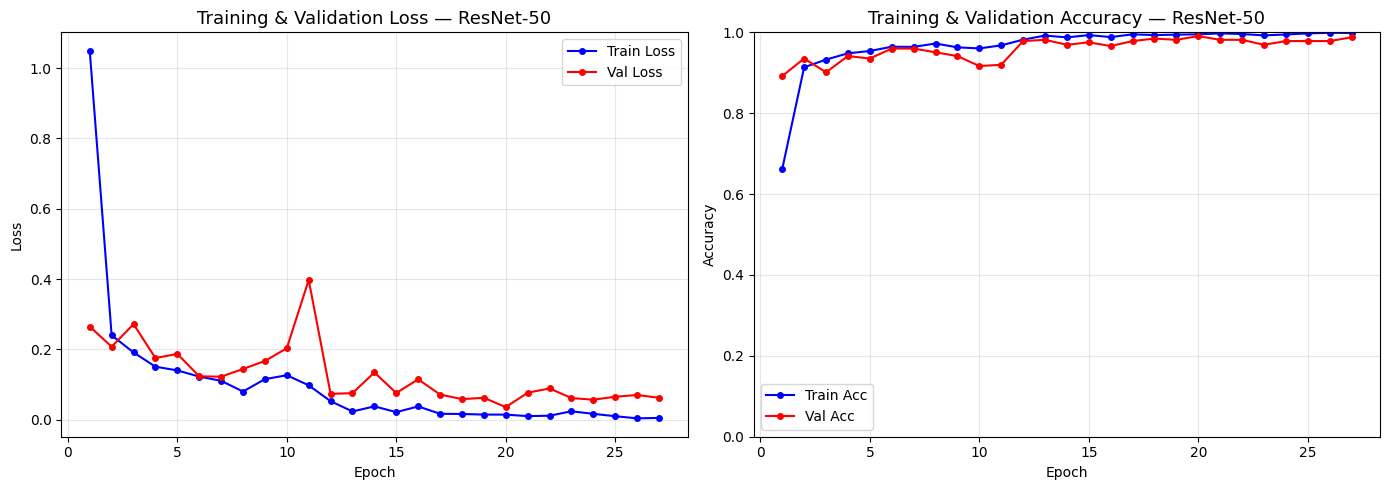

Plot disimpan: /content/drive/MyDrive/MODEL_RESNET50/resnet50_training_history.png


In [ ]:
# Cell 8: Plot training history (loss & accuracy)
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(x, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
axes[0].set_title('Training & Validation Loss — ResNet-50', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, history['train_acc'], 'b-o', label='Train Acc', markersize=4)
axes[1].plot(x, history['val_acc'],   'r-o', label='Val Acc',   markersize=4)
axes[1].set_title('Training & Validation Accuracy — ResNet-50', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(SAVE_DIR, 'resnet50_training_history.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot disimpan: {plot_path}')

## Cell 9 — Evaluasi Test Set + Confusion Matrix

Memuat best model...
Best model berhasil dimuat



Testing: 100%|██████████| 11/11 [01:33<00:00,  8.50s/it]


  HASIL EVALUASI TEST SET — ResNet-50
  Accuracy  : 0.9763  (97.63%)
  Precision : 0.9771  (weighted)
  Recall    : 0.9763  (weighted)
  F1-Score  : 0.9760  (weighted)

Classification Report per Kelas:
                                        precision    recall  f1-score   support

                            apple_scab       1.00      1.00      1.00        28
                        bacterial_spot       0.96      0.96      0.96        28
                             black_rot       1.00      1.00      1.00        28
                      cedar_apple_rust       1.00      1.00      1.00        28
                            cercospora       0.96      0.82      0.88        28
                           common_rust       0.97      1.00      0.98        29
                          early_blight       1.00      1.00      1.00        28
                       grape_black_rot       0.97      1.00      0.98        28
              grape_esca_black_measles       1.00      1.00      1.00        

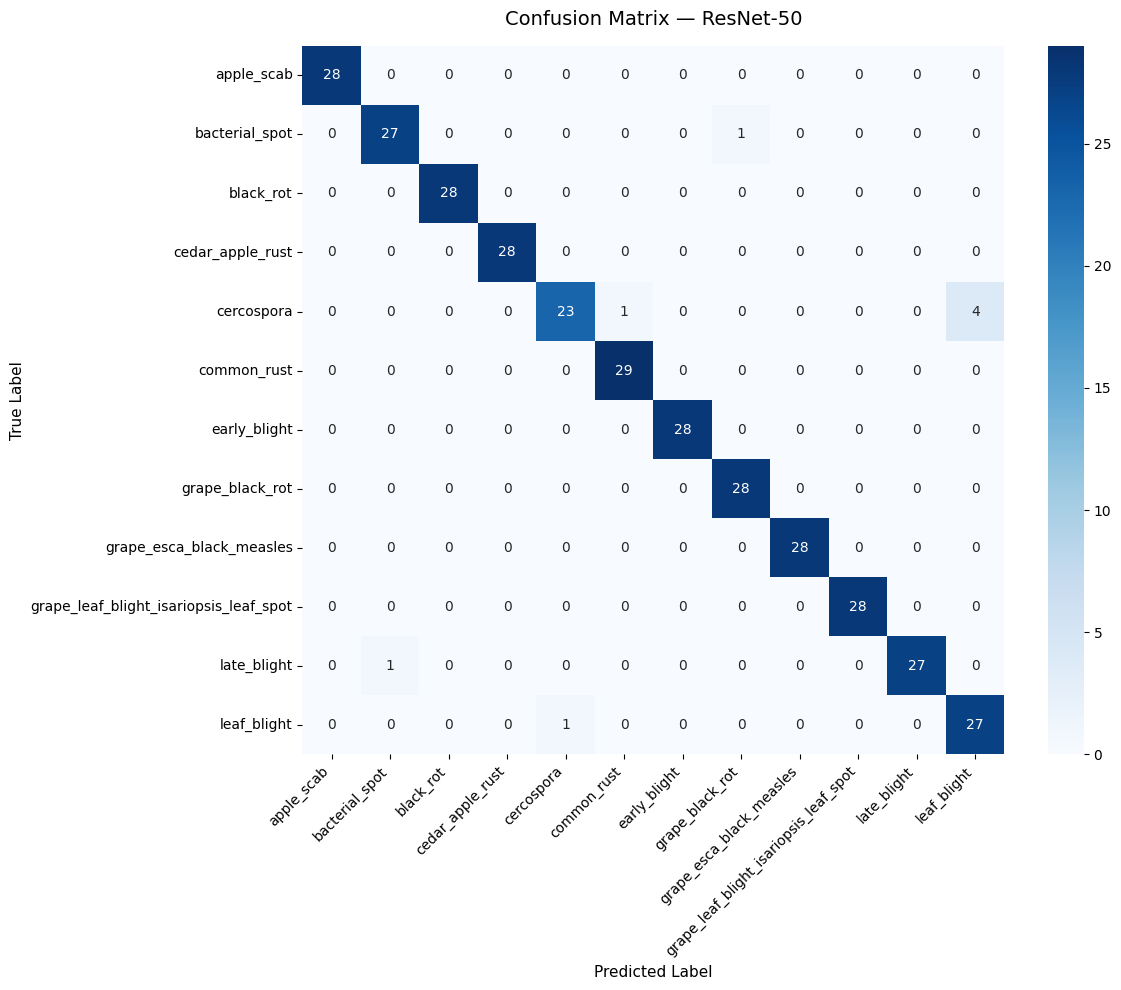

Confusion matrix disimpan: /content/drive/MyDrive/MODEL_RESNET50/resnet50_confusion_matrix.png


In [ ]:
# Cell 9: Evaluasi test set + Confusion matrix

# ── Load best model ──────────────────────────────────────────
print('Memuat best model...')
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()
print('Best model berhasil dimuat')
print()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(DEVICE)
        outputs = model(pixel_values=images).logits
        preds   = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Metrics ──────────────────────────────────────────────────
acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='weighted')
rec  = recall_score(all_labels, all_preds, average='weighted')
f1   = f1_score(all_labels, all_preds, average='weighted')

print('=' * 48)
print('  HASIL EVALUASI TEST SET — ResNet-50')
print('=' * 48)
print(f'  Accuracy  : {acc:.4f}  ({acc * 100:.2f}%)')
print(f'  Precision : {prec:.4f}  (weighted)')
print(f'  Recall    : {rec:.4f}  (weighted)')
print(f'  F1-Score  : {f1:.4f}  (weighted)')
print('=' * 48)
print()

# ── Classification report per kelas ──────────────────────────
print('Classification Report per Kelas:')
print(classification_report(all_labels, all_preds, target_names=CLASSES))

# ── Confusion matrix heatmap ─────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASSES,
    yticklabels=CLASSES
)
plt.title('Confusion Matrix — ResNet-50', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

cm_path = os.path.join(SAVE_DIR, 'resnet50_confusion_matrix.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Confusion matrix disimpan: {cm_path}')

## Cell 10 — Simpan Model & Metrics

In [ ]:
# Cell 10: Simpan model & metrics ke JSON

# ── Simpan final model ───────────────────────────────────────
final_model_path = os.path.join(SAVE_DIR, 'resnet50_final.pt')
torch.save({
    'model_state_dict' : model.state_dict(),
    'class_to_idx'     : train_dataset.class_to_idx,
    'classes'          : CLASSES,
    'model_name'       : MODEL_NAME,
    'num_classes'      : NUM_CLASSES,
    'image_size'       : IMAGE_SIZE,
}, final_model_path)

# ── Simpan metrics JSON ──────────────────────────────────────
epochs_ran = len(history['train_loss'])
metrics_summary = {
    'model'          : MODEL_NAME,
    'test_accuracy'  : round(float(acc), 4),
    'test_precision' : round(float(prec), 4),
    'test_recall'    : round(float(rec), 4),
    'test_f1'        : round(float(f1), 4),
    'epochs_trained' : epochs_ran,
    'best_val_loss'  : round(float(early_stopping.best_loss), 4),
}
metrics_path = os.path.join(SAVE_DIR, 'resnet50_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print('Semua file tersimpan di Google Drive:')
print(f'  resnet50_best.pt      -> {best_model_path}')
print(f'  resnet50_final.pt     -> {final_model_path}')
print(f'  resnet50_metrics.json -> {metrics_path}')
print(f'  training_history.png  -> {plot_path}')
print(f'  confusion_matrix.png  -> {cm_path}')
print()
print('Ringkasan Akhir:')
for k, v in metrics_summary.items():
    print(f'  {k:<20}: {v}')

Semua file tersimpan di Google Drive:
  resnet50_best.pt      -> /content/drive/MyDrive/MODEL_RESNET50/resnet50_best.pt
  resnet50_final.pt     -> /content/drive/MyDrive/MODEL_RESNET50/resnet50_final.pt
  resnet50_metrics.json -> /content/drive/MyDrive/MODEL_RESNET50/resnet50_metrics.json
  training_history.png  -> /content/drive/MyDrive/MODEL_RESNET50/resnet50_training_history.png
  confusion_matrix.png  -> /content/drive/MyDrive/MODEL_RESNET50/resnet50_confusion_matrix.png

Ringkasan Akhir:
  model               : microsoft/resnet-50
  test_accuracy       : 0.9763
  test_precision      : 0.9771
  test_recall         : 0.9763
  test_f1             : 0.976
  epochs_trained      : 27
  best_val_loss       : 0.0358
